--- Matriz Original ---
Matrix([[3, 2, 6], [2, 3, 5]])

--- Matriz em Forma Escalonada Reduzida (RREF) ---
Matrix([[1, 0, 8/5], [0, 1, 3/5]])

Solução encontrada: x = 8/5, y = 3/5


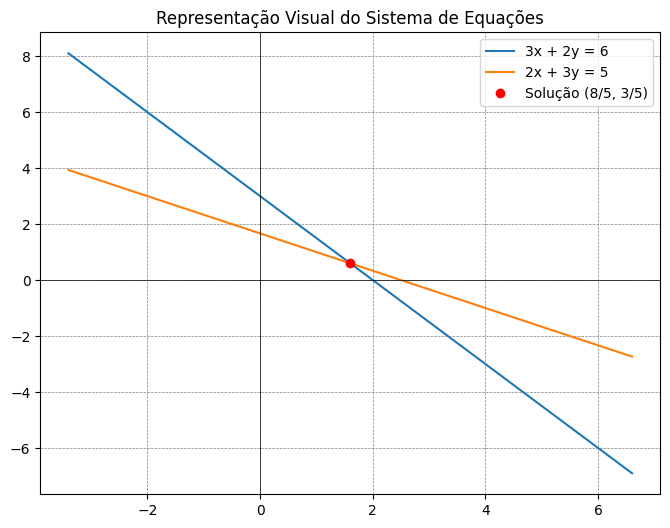

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import Matrix, solve_linear_system, symbols

def resolver_sistema(matriz_lista):
    # 1. Definir símbolos e Matriz
    x, y = symbols('x y')
    A = Matrix(matriz_lista)

    print("--- Matriz Original ---")
    print(A)

    # 2. Escalonamento (Diagonalização da parte dos coeficientes)
    # rref() retorna a forma escalonada reduzida e os índices das colunas pivô
    A_reduzida, pivôs = A.rref()

    print("\n--- Matriz em Forma Escalonada Reduzida (RREF) ---")
    print(A_reduzida)

    # 3. Extrair soluções
    sol_x = A_reduzida[0, 2]
    sol_y = A_reduzida[1, 2]

    print(f"\nSolução encontrada: x = {sol_x}, y = {sol_y}")

    # 4. Visualização Gráfica
    plt.figure(figsize=(8, 6))

    # Criar intervalo de valores para x
    x_vals = np.linspace(float(sol_x) - 5, float(sol_x) + 5, 400)

    # Isolar y nas equações originais para plotar:
    # Eq 1: a*x + b*y = c  => y = (c - a*x) / b
    # Eq 2: d*x + e*y = f  => y = (f - d*x) / e

    y1 = (matriz_lista[0][2] - matriz_lista[0][0] * x_vals) / matriz_lista[0][1]
    y2 = (matriz_lista[1][2] - matriz_lista[1][0] * x_vals) / matriz_lista[1][1]

    plt.plot(x_vals, y1, label=f'{matriz_lista[0][0]}x + {matriz_lista[0][1]}y = {matriz_lista[0][2]}')
    plt.plot(x_vals, y2, label=f'{matriz_lista[1][0]}x + {matriz_lista[1][1]}y = {matriz_lista[1][2]}')

    # Marcar a solução
    plt.plot(float(sol_x), float(sol_y), 'ro', label=f'Solução ({sol_x}, {sol_y})')

    plt.axhline(0, color='black',linewidth=0.5)
    plt.axvline(0, color='black',linewidth=0.5)
    plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
    plt.legend()
    plt.title('Representação Visual do Sistema de Equações')
    plt.show()

# Exemplo de uso com a matriz vista em aula:
# | 3 2 6 |
# | 2 3 5 |
minha_matriz = [[3, 2, 6], [2, 3, 5]]
resolver_sistema(minha_matriz)